<a href="https://colab.research.google.com/github/Malak-Amr/10-Projects-challenge-using-html-css-only/blob/main/crimes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("/crimes.csv")
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nInformation about data types and non-null values:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe(include='all'))

Missing values in each column:
DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64

Information about data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 1

### Handling Missing Values

We will fill the missing values in the `Vict Sex` and `Vict Descent` columns with the mode, and fill the missing values in `Weapon Desc` with 'UNKNOWN'.

In [ ]:
mode_vict_sex = df['Vict Sex'].mode()[0]
df['Vict Sex'].fillna(mode_vict_sex, inplace=True)

mode_vict_descent = df['Vict Descent'].mode()[0]
df['Vict Descent'].fillna(mode_vict_descent, inplace=True)

df['Weapon Desc'].fillna('UNKNOWN', inplace=True)

print("Missing values after processing:")
print(df.isnull().sum())

Missing values after processing:
DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA NAME       0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Weapon Desc     0
Status Desc     0
LOCATION        0
dtype: int64


/tmp/ipykernel_1862/2045457543.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Vict Sex'].fillna(mode_vict_sex, inplace=True)
/tmp/ipykernel_1862/2045457543.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

### Data Type Conversion

We will convert the `Date Rptd` and `DATE OCC`columns to `datetime` type.

In [21]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

print("Information about data after processing:")
df.info()

Information about data after processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         185715 non-null  int64         
 1   Date Rptd     185715 non-null  datetime64[ns]
 2   DATE OCC      185715 non-null  datetime64[ns]
 3   TIME OCC      185715 non-null  int64         
 4   AREA NAME     185715 non-null  object        
 5   Crm Cd Desc   185715 non-null  object        
 6   Vict Age      185715 non-null  int64         
 7   Vict Sex      185715 non-null  object        
 8   Vict Descent  185715 non-null  object        
 9   Weapon Desc   185715 non-null  object        
 10  Status Desc   185715 non-null  object        
 11  LOCATION      185715 non-null  object        
dtypes: datetime64[ns](2), int64(3), object(7)
memory usage: 17.0+ MB


### Data Analysis

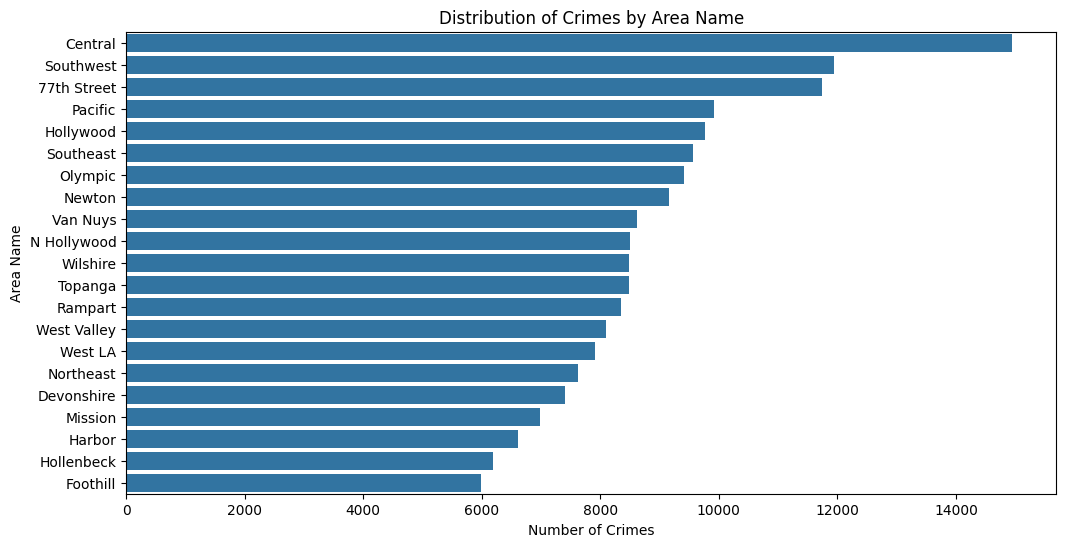

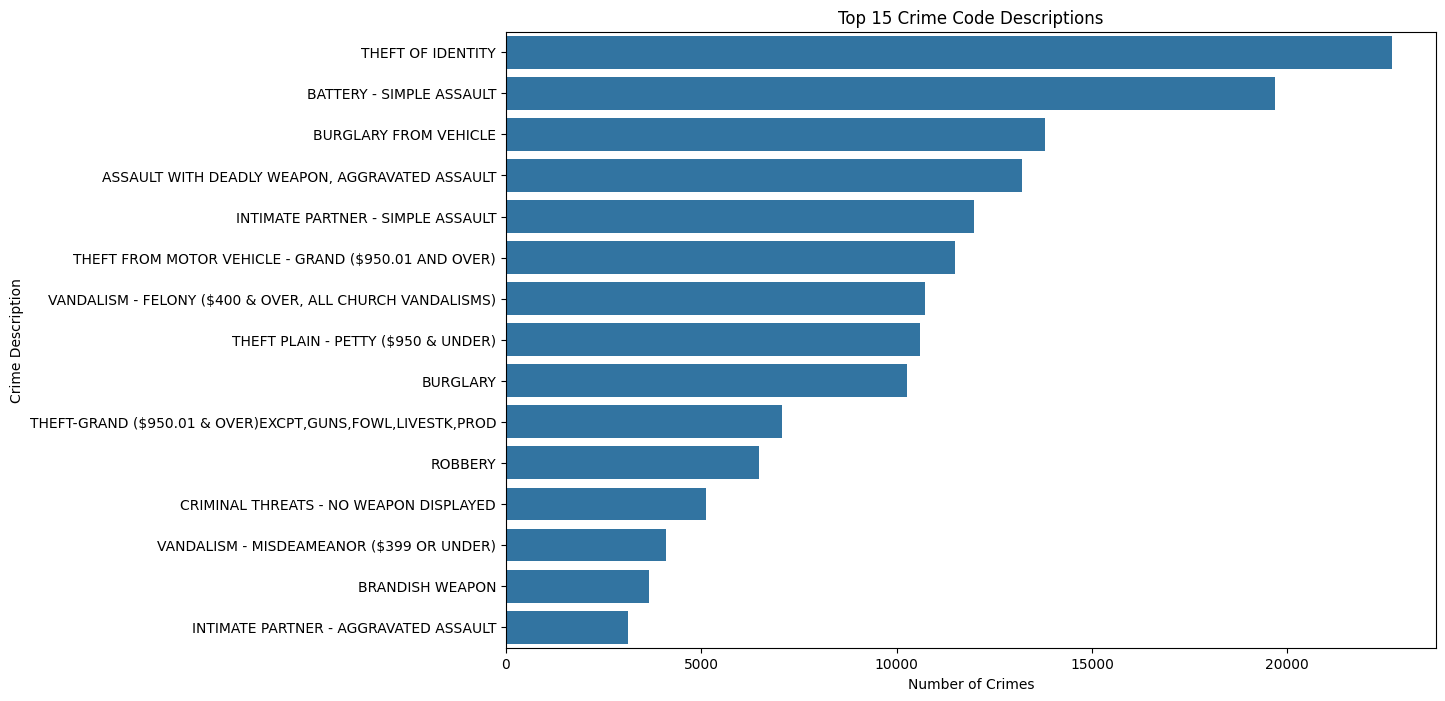

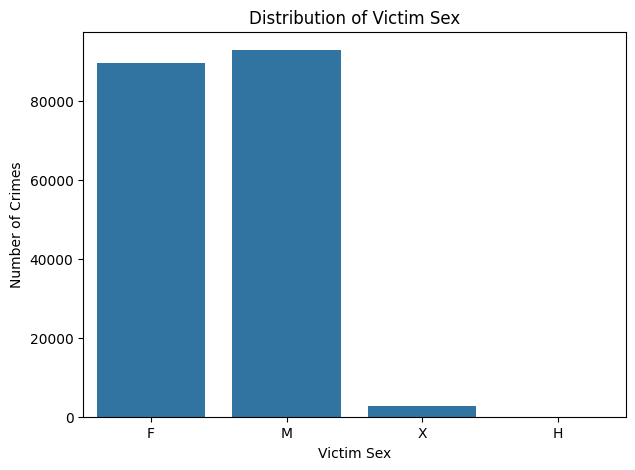

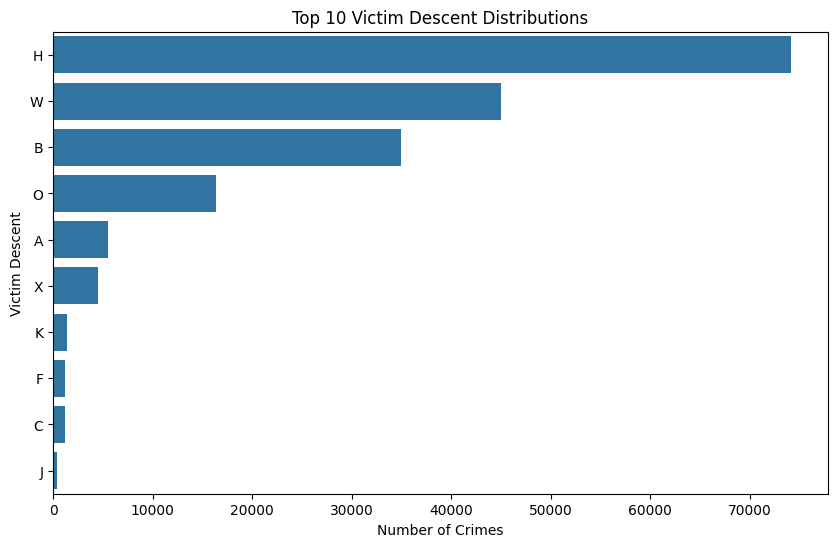

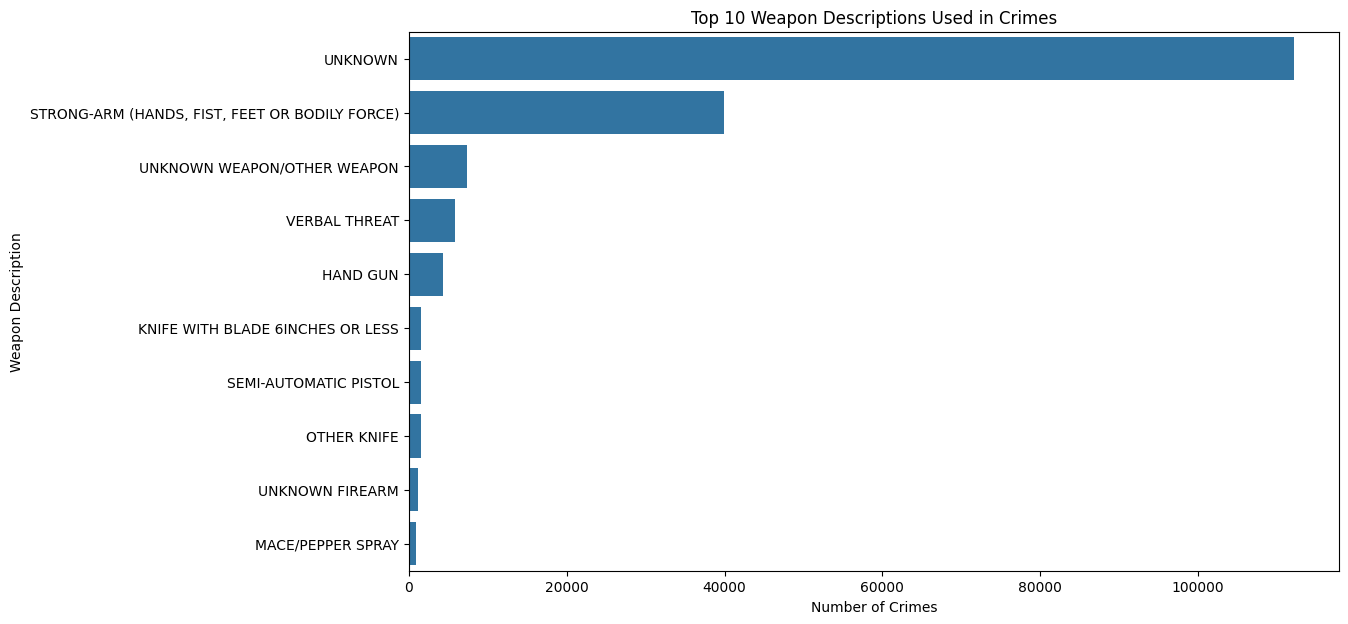

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze 'AREA NAME' distribution
plt.figure(figsize=(12, 6))
sns.countplot(y='AREA NAME', data=df, order=df['AREA NAME'].value_counts().index)
plt.title('Distribution of Crimes by Area Name')
plt.xlabel('Number of Crimes')
plt.ylabel('Area Name')
plt.show()

# Analyze 'Crm Cd Desc' (Crime Code Description) distribution
plt.figure(figsize=(12, 8))
sns.countplot(y='Crm Cd Desc', data=df, order=df['Crm Cd Desc'].value_counts().index[:15]) # Top 15 crimes
plt.title('Top 15 Crime Code Descriptions')
plt.xlabel('Number of Crimes')
plt.ylabel('Crime Description')
plt.show()

# Analyze 'Vict Sex' distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Vict Sex', data=df)
plt.title('Distribution of Victim Sex')
plt.xlabel('Victim Sex')
plt.ylabel('Number of Crimes')
plt.show()

# Analyze 'Vict Descent' distribution (Top 10)
plt.figure(figsize=(10, 6))
sns.countplot(y='Vict Descent', data=df, order=df['Vict Descent'].value_counts().index[:10])
plt.title('Top 10 Victim Descent Distributions')
plt.xlabel('Number of Crimes')
plt.ylabel('Victim Descent')
plt.show()

# Analyze 'Weapon Desc' distribution (Top 10)
plt.figure(figsize=(12, 7))
sns.countplot(y='Weapon Desc', data=df, order=df['Weapon Desc'].value_counts().index[:10])
plt.title('Top 10 Weapon Descriptions Used in Crimes')
plt.xlabel('Number of Crimes')
plt.ylabel('Weapon Description')
plt.show()


###Numerical Variables


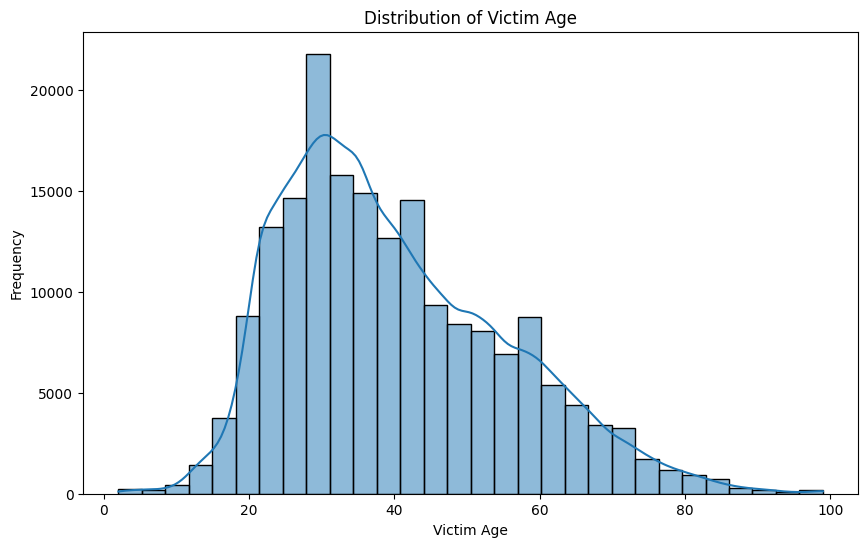

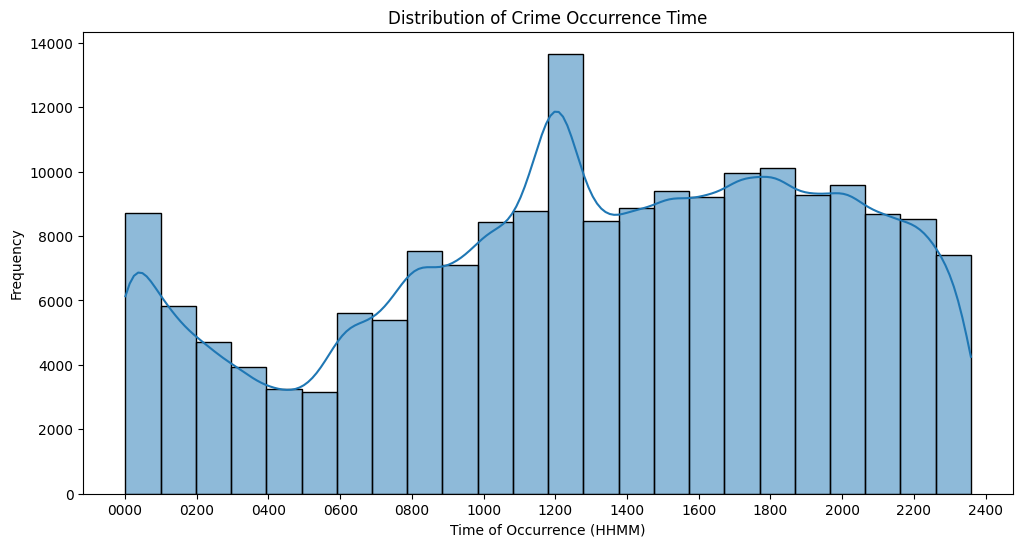

In [23]:
# Analyze 'Vict Age' distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Vict Age'], bins=30, kde=True)
plt.title('Distribution of Victim Age')
plt.xlabel('Victim Age')
plt.ylabel('Frequency')
plt.show()

# Analyze 'TIME OCC' (Time Occurred) distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['TIME OCC'], bins=24, kde=True) # Assuming time is in 2400 format
plt.title('Distribution of Crime Occurrence Time')
plt.xlabel('Time of Occurrence (HHMM)')
plt.ylabel('Frequency')
plt.xticks(range(0, 2401, 200), [f'{h:04d}' for h in range(0, 2401, 200)])
plt.show()


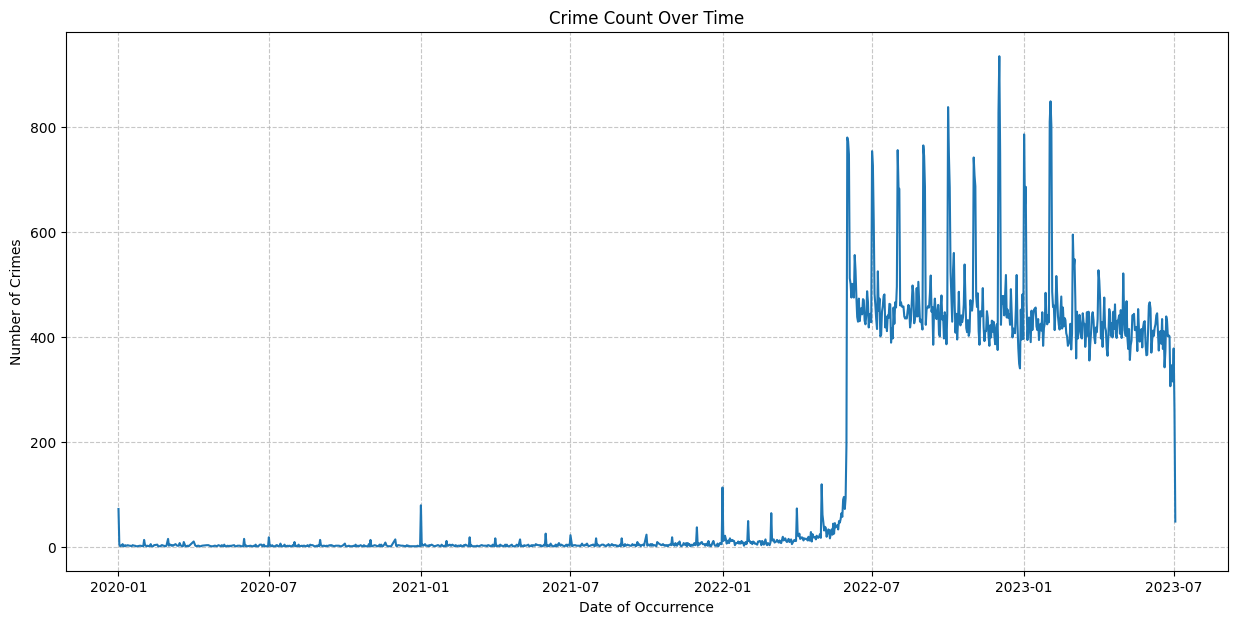

In [24]:
# Analyze crime trends over time
# Group by 'DATE OCC' and count occurrences
crime_over_time = df.groupby('DATE OCC').size().reset_index(name='Crime Count')

plt.figure(figsize=(15, 7))
sns.lineplot(x='DATE OCC', y='Crime Count', data=crime_over_time)
plt.title('Crime Count Over Time')
plt.xlabel('Date of Occurrence')
plt.ylabel('Number of Crimes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### (Crime Hotspots)

To analyze crime hotspots, we will calculate the total number of crimes for each area

In [ ]:
# Calculate crime counts by 'AREA NAME'
crime_by_area = df['AREA NAME'].value_counts().reset_index()
crime_by_area.columns = ['AREA NAME', 'Crime Count']

print("Crime Counts by Area Name (Top 10 Hotspots):")
display(crime_by_area.head(10))

# Optionally, visualize the top N crime areas
plt.figure(figsize=(12, 7))
sns.barplot(x='Crime Count', y='AREA NAME', data=crime_by_area.head(10), palette='viridis')
plt.title('Top 10 Crime Hotspots by Area Name')
plt.xlabel('Number of Crimes')
plt.ylabel('Area Name')
plt.show()